## Custom Drift Compensation Drift



In [ ]:
import math
import random
import numpy as np
import scipy.io

# set the seed for reproducibility
np.random.seed(5)

def compute_MSE(x:np.array, y:np.array, verbose: bool = True )->float:
    """
    A function to compute the mean square error between two arrays

    Args:
        x (np.array): the first array
        y (np.array): the second array
        verbose (bool): a flag to print some information about the error

    Returns:
        float: the mean square erro
    """

    diff = abs(x - y)
    indexes = np.argsort(diff)
    if verbose:
        print("Indexes of the most significant terms: ", indexes[-10:][::-1])
        print("Values of the most significant terms: ", diff[indexes[-10:][::-1]])
    # compute the error using the ideal currents and MSE
    mse = np.mean(diff**2)
    if verbose:
        print("MSE: ", mse)
    
    return mse

def compute_SUM_DIFF_SQR(x:np.array, y:np.array, verbose: bool = True )->float:
    """
    A function to compute difference between the sums of two arrays
    """    
    # check that all the values of x and y are positive
    if np.any(x<0) or np.any(y<0):
        # Print the values of the arrays that are negative
        if np.any(x<0):
            print("Values of x that are negative: ", x[x<0])
        if np.any(y<0):
            print("Values of y that are negative: ", y[y<0])
        raise ValueError("All the values of the arrays should be positive")

    d = (np.sum(x)-np.sum(y))**2
    if verbose:
        print("Difference between the sums: ", d)
    return d

""" Helper functions to conpute the drift exponent nu"""
def mu_nu(g_t:float)->float:
    g_t = max(g_t, 0.1e-9)
    return min(max(-0.0155*np.log(g_t)+0.0244, 0.049),0.1)

def sigma_nu(g_t:float)->float:
    g_t = max(g_t, 0.1e-9)
    return min(max(-0.0125*np.log(g_t)-0.0059, 0.008),0.045)



def g_drift_IBM(g_t:float, t_c:float, t:float)->float:
    """
    A function to model the drift of the conductance value. For simplicity, suppose the g_prog = g_t passed as argument

    Args:
        g_t (float): the target conductance value
        t_c (float): the time at which we know the conductance value g_prog
        t (float): the time at which we want to know the conductance value

    Returns:
        float: the conductance value at time t
    
    """
    mu = mu_nu(g_t)
    sigma = sigma_nu(g_t)
    nu = np.random.normal(mu, sigma)
    return g_t*(t/t_c)**(-nu)


def g_drift_median_IBM(g_t:float, t_c:float, t:float)->float:
    """
    A function to model only the drift of the conductances only considering the median value of the drift exponent nu

    Args:
        g_t (float): the target conductance value
        t_c (float): the time at which we know the conductance value g_prog
        t (float): the time at which we want to know the conductance value

    Returns:
        float: the conductance value at time t
    
    """
    mu = mu_nu(g_t)
    return g_t*(t/t_c)**(-mu)


class CustomDrifter:

    def __init__(self, file_name:str):
        """ A class to import the median and std deviation values for the drift of the conductance value out"""
        mat = scipy.io.loadmat(file_name)
        self.types = mat['str'][0]
        self.types = [str(self.types[i][0]) for i in range(len(self.types))]
        self.mu = mat['ww_mdn'] # a list of median values for the different values of target conductances (differential), based on the type of noise
        self.sigma = mat['ww_std'] # a list of std deviation values for the different values of target conductances (differental), based on the type of noise
        self.mu_g = mat['gg_mdn'] # a list of median values for the different values of target conductances (single), based on the type of noise
        self.sigma_g = mat['gg_std'] # a list of std deviation values for the different values of target conductances (single), based on the type of noise

    def expose_types(self):
        return self.types
    
    def g_drift_custom(self, g_t:float, typ: str, levels: int, g_max: float, median:bool = True, std: bool = True)->float:
        """
        A function to model the drift of the conductance value based on the type of noise. The conductances considered 
        are the single values (non-compensated)

        Args:
            g_t (float): the target conductance value (g_t in the range [0 uS, 80 uS])
            typ (str): the type of noise to be considered

        Returns:
            float: the conductance value 'at time t'
        """
        if levels >= 9 and levels < 1 and levels%1 != 0:
            raise ValueError("The number of levels should be between 1 and 9 and should be odd")
        
        # access the median and std deviation values based on the type of noise
        mu = [self.mu_g[i][self.types.index(typ)] for i in range(self.mu_g.shape[0])]
        sigma = [self.sigma_g[i][self.types.index(typ)] for i in range(self.sigma_g.shape[0])]
        # append 0 to mu and sigma
        #print(mu)
        mu = [0.] + mu
        sigma = [0.] + sigma
        # interpolate the values at the number of levels selected
        g_range = np.linspace(0, g_max, levels)
        mu = np.interp(g_range, np.linspace(0, g_max, len(mu)), mu)
        sigma = np.interp(g_range, np.linspace(0, g_max, len(sigma)), sigma)
        level = round((g_t/g_max)*(levels-1))
        #print(level)

        mu = mu[level]
        sigma = sigma[level]
        if median and std:
            g_drifted = float((mu + np.random.normal(0, sigma)))
            if g_drifted < 0:
                g_drifted = 0.
            return g_drifted
        elif median:
            g_drifted = float(mu)
            return g_drifted
        elif std:
            g_drifted = float(np.random.normal(0, sigma) if np.random.normal(0, sigma) > 0. else 0.)
            return g_drifted
        else:
            raise ValueError("You should choose at least one of the median or std deviation values")


    def w_drift_custom(self, w_t:float, typ: str, levels: int, g_max: float, median : bool = True, std: bool = True)->float:
        """
        A function to model the drift of the conductance value based on the type of noise. The drifted conductance values considered
        are the differential values (already compensated)

        Args:
            w_t (float): the target conductance value (w_t in the range [-40 uS, 40 uS])
            typ (str): the type of noise to be considered

        Returns:
            float: the conductance value 'at time t'
        
        """
        if(levels >= 9 and levels < 1 and levels%1 != 0):
            raise ValueError("The number of levels should be between 1 and 9 and should be odd")

        # access the median and std deviation values based on the type of noise
        mu = [self.mu[i][self.types.index(typ)] for i in range(self.mu.shape[0])]
        sigma = [self.sigma[i][self.types.index(typ)] for i in range(self.sigma.shape[0])]
        # get rid of the negative values
        mu = mu[len(mu)//2:]
        sigma = sigma[len(sigma)//2:]
        # interpolate the values at the number of levels
        g_range = np.linspace(0, g_max, levels)
        mu = np.interp(g_range, np.linspace(0, g_max, len(mu)), mu)
        sigma = np.interp(g_range, np.linspace(0, g_max, len(sigma)), sigma)
        # determine to which level the target conductance belongs to
        level = round((w_t/g_max)*(levels-1))
        # get the median and std deviation values for the target conductance
        mu = mu[level]
        sigma = sigma[level]
        if median and std:
            g_drifted = float((mu + np.random.normal(0, sigma)))
            if g_drifted < 0:
                g_drifted = 0.
            return g_drifted
        elif median:
            g_drifted = float(mu)
            return g_drifted
        elif std:
            g_drifted = float(np.random.normal(0, sigma) if np.random.normal(0, sigma) > 0. else 0.)
            return g_drifted
        else:
            raise ValueError("You should choose at least one of the median or std deviation values")
        
    
    # hook to drift the conductance value
    def __call__(self, g_t:float, typ: str, levels: int, g_max: float):
        #return self.w_drift_custom(g_t, typ, levels, g_max) 
        return self.g_drift_custom(g_t, typ, levels, g_max)


def DAC_quantizer(input:np.array, bits:int, Vdd: float, amax: float)->np.array:
    """
    A function to model the quantization operation user in the DAC

    Args:
        input (np.array): the input values to be quantizedm(int32)
        bits (int): the number of bits for the quantization
        Vdd (float): the supply voltage used
        amax (float): the maximum value of the input
    
    Returns:
        output (np.array): the quantized values

    """
    # rescale the input values
    input = input/amax*Vdd
    # define the quantization levels
    levels = 2**bits
    # define the step size
    delta = Vdd/levels
    # quantize the input values
    output = np.round(input/delta)*delta
    return output
    
    
# define the number of levels, lines and columns
n_levels = 5
N = 64
M = 32

# define the supply voltage, max conductance value, max_input
Vdd = 0.3 # V
max_g = 80e-6 # S
max_input = 10



In [2]:
CustomDrifter('../data/matlab/4bit.mat').g_drift_custom(11e-6, 'Prog', 5, 80e-6, median=True, std=False)

2.1709575208636695e-05

The inputs are ([0,10]):  [ 0.  0. 10. 10. 10. 10. 10. 10. 10. 10.]
The voltages are ([0,10]):  [0.  0.  0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3]
The currents are ([0,10]):  [7.80e-05 5.40e-05 6.60e-05 4.20e-05 9.00e-05 5.40e-05 1.02e-04 8.40e-05
 8.40e-05 6.60e-05]
[66 43]


<Figure size 640x480 with 0 Axes>

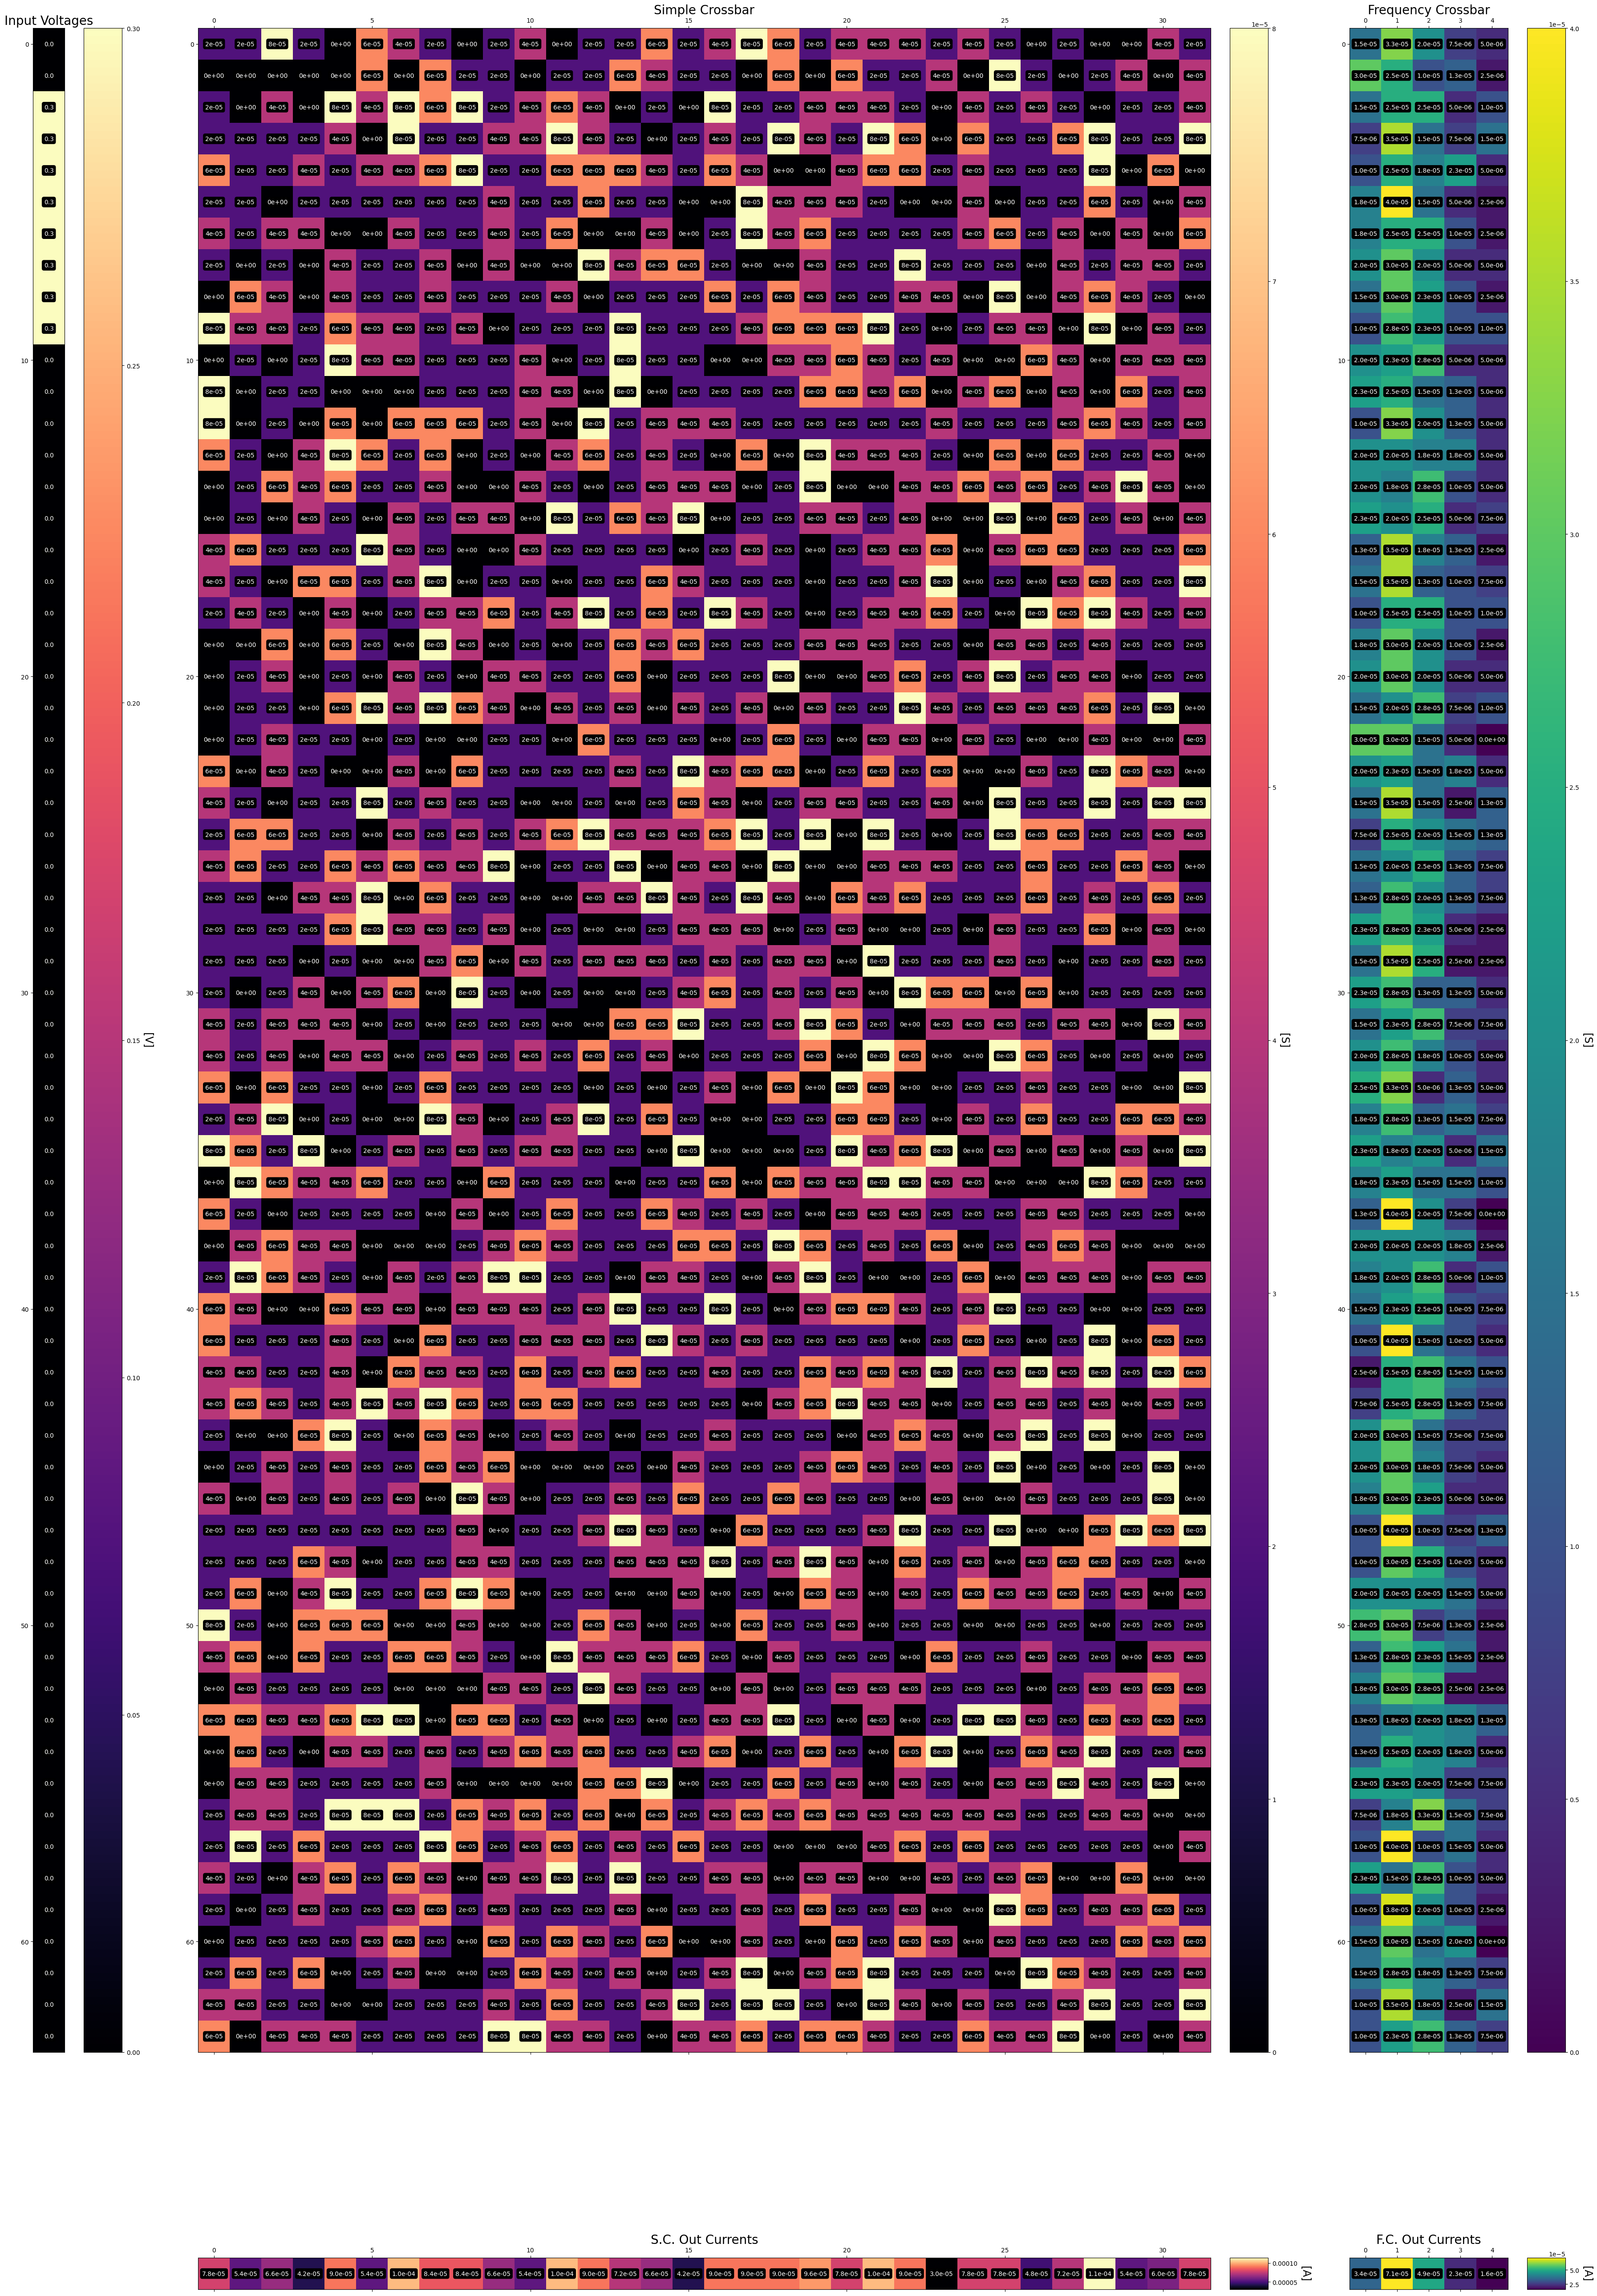

In [3]:
# plot the two crossbars as colormaps with values
import matplotlib.pyplot as plt


# define the cossbar
simple_crossbar = np.zeros((N,M)) 
frequency_crossbar = np.zeros((N,n_levels))
quantized_frequency_crossbar = np.zeros((N,n_levels))

# randomly initialize the crossbar with one of the n_levels
# for now suppose the distribution is NORMAL (positive)
for i in range(N):
    simple_crossbar[i] = np.clip(abs(np.random.normal(0, max_g/2, M)),0,max_g)
    # quantize the conductances
    simple_crossbar[i] = np.round(simple_crossbar[i]/max_g*(n_levels-1)) * max_g/(n_levels-1)
    # count the frequency of appearance of each level for each line in the crossbar
    frequency_crossbar[i] = np.bincount((simple_crossbar[i]*(n_levels-1.)/max_g).astype(int), minlength=n_levels)
    frequency_crossbar[i] = frequency_crossbar[i]/np.sum(frequency_crossbar[i])*max_g # / M + max_g

    # also quantize the conductances for the frequency crossbar
    quantized_frequency_crossbar[i] = np.round(frequency_crossbar[i]/max_g*(n_levels))*max_g/(n_levels-1)


# Define the input tensor
inputs = np.zeros(N)
inputs[2:10] = 10
inputs[15:20] = 5
print("The inputs are ([0,10]): ",inputs[:10])
# quantize the input voltages
bits = 0
voltages = DAC_quantizer(inputs, bits, Vdd, max_input)
print("The voltages are ([0,10]): ",voltages[:10])

# compute the output currents for simple crossbar
currents = np.zeros(M)
for i in range(M):
    currents[i] = np.dot(simple_crossbar[:,i], voltages)
print("The currents are ([0,10]): ", currents[:10])

# compute the output currents for frequency crossbar
currents_freq = np.zeros(n_levels)
for i in range(n_levels):
    currents_freq[i] = np.dot(frequency_crossbar[:,i], voltages)

currents_quantized_freq = np.zeros(n_levels)
for i in range(n_levels):
    currents_quantized_freq[i] = np.dot(quantized_frequency_crossbar[:,i], voltages)
    

# ============================================================================= PLOTTING =============================================================================
plt.subplots_adjust(wspace=0.4, 
                    hspace=0.4)
figsize = 1 *np.array(simple_crossbar.shape) + 2
figsize[-1] += frequency_crossbar.shape[-1] + 4
print(figsize)
fig, axs = plt.subplots(2, 3, figsize=figsize[::-1], gridspec_kw={'width_ratios': [1,simple_crossbar.shape[-1], frequency_crossbar.shape[-1]], 'height_ratios': [simple_crossbar.shape[0],1]})

# Simple Crossbar
im = axs[0,1].matshow(simple_crossbar, cmap="magma",origin='upper' )
for (i,j), z in np.ndenumerate(simple_crossbar):
    axs[0,1].text(j, i, '{:0.0e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = (simple_crossbar.shape[0])/(simple_crossbar.shape[1])
cax = fig.add_axes([axs[0,1].get_position().x1+0.01,axs[0,1].get_position().y0,0.02,axs[0,1].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("[S]", rotation=-90, va="bottom", fontsize=17)
axs[0,1].set_title("Simple Crossbar", fontsize=20)

# Frequency Crossbar
im = axs[0,2].matshow(frequency_crossbar, cmap="viridis",origin='upper' )
for (i,j), z in np.ndenumerate(frequency_crossbar):
    axs[0,2].text(j, i, '{:0.1e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = frequency_crossbar.shape[0]/frequency_crossbar.shape[1]
cax = fig.add_axes([axs[0,2].get_position().x1+0.01,axs[0,2].get_position().y0,0.02,axs[0,2].get_position().height])
cbar = plt.colorbar(im, cax=cax)

cbar.ax.set_ylabel("[S]", rotation=-90, va="bottom", fontsize=17)    
axs[0,2].set_title("Frequency Crossbar", fontsize=20)

# Input voltages
im = axs[0,0].matshow(voltages.reshape(-1,1), cmap="magma",origin='upper' )
for i, z in enumerate(voltages):
    axs[0,0].text(0, i, '{:0.1f}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = 1/voltages.shape[0]
cax = fig.add_axes([axs[0,0].get_position().x1+0.01,axs[0,0].get_position().y0,0.02,axs[0,0].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("[V]", rotation=-90, va="bottom", fontsize=17)
axs[0,0].set_xticks([])
axs[0,0].set_title("Input Voltages", fontsize=20)

# Simpre crossbar outputs
im = axs[1,1].matshow(currents.reshape(1,-1), cmap="magma",origin='upper' )
for i, z in enumerate(currents):
    axs[1,1].text(i, 0, '{:0.1e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = currents.shape[0]/1
cax = fig.add_axes([axs[1,1].get_position().x1+0.01,axs[1,1].get_position().y0,0.02,axs[1,1].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("[A]", rotation=-90, va="bottom", fontsize=17)
axs[1,1].set_yticks([])
axs[1,1].set_title("S.C. Out Currents", fontsize=20)

# Frequency crossbar outputs
im = axs[1,2].matshow(currents_freq.reshape(1,-1), cmap="viridis",origin='upper' )
for i, z in enumerate(currents_freq):
    axs[1,2].text(i, 0, '{:0.1e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = currents_freq.shape[0]/1
cax = fig.add_axes([axs[1,2].get_position().x1+0.01,axs[1,2].get_position().y0,0.02,axs[1,2].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("[A]", rotation=-90, va="bottom", fontsize=17)
axs[1,2].set_yticks([])
axs[1,2].set_title("F.C. Out Currents", fontsize=20)





# delete the axes for axs[1,0]
axs[1,0].axis('off')

plt.show()

In [4]:


# recompute the currents using a reference value for the voltages  to apply the IBM correction
#Vref = np.concatenate([np.array([Vdd]*(N//2)), np.array([0]*(N//2))])
Vref = np.array([Vdd]*N)
currents_ref = np.zeros(M)
for i in range(M):
    currents_ref[i] = np.dot(simple_crossbar[:,i], Vref)
print("The reference currents at initialization are ([0,10]): ", currents_ref[:10])


The reference currents at initialization are ([0,10]):  [0.000564 0.000552 0.00051  0.000498 0.000684 0.000534 0.000588 0.000648
 0.0006   0.000552]


['Prog', '1d,RT', '30d,RT', '1d,60°C', '1d,90°C', '1d,120°C', '1d,150°C', '1d,180°C']
Chosen type:  30d,RT
The g_values are:  [0.e+00 2.e-05 4.e-05 6.e-05 8.e-05]
Currents on the drifted SIMPLE crossbar for the chosen input voltages ([0:10]):  [4.59298277e-05 2.91968264e-05 3.24537199e-05 1.90163170e-05
 5.67910057e-05 2.60569407e-05 6.09193254e-05 4.91801508e-05
 5.06403366e-05 3.18084515e-05]
Currents on the drifted FREQUENCY crossbar for the chosen input voltages ([0:10]):  [1.23691968e-05 3.75911474e-05 1.92688360e-05 1.40189407e-06
 1.97798141e-06]
Currents on the drifted QUANTIZED FREQUENCY crossbar for the chosen input voltages ([0:10]):  [1.74459780e-05 5.32710308e-05 2.85729912e-05 9.15267311e-06
 7.86968317e-06]


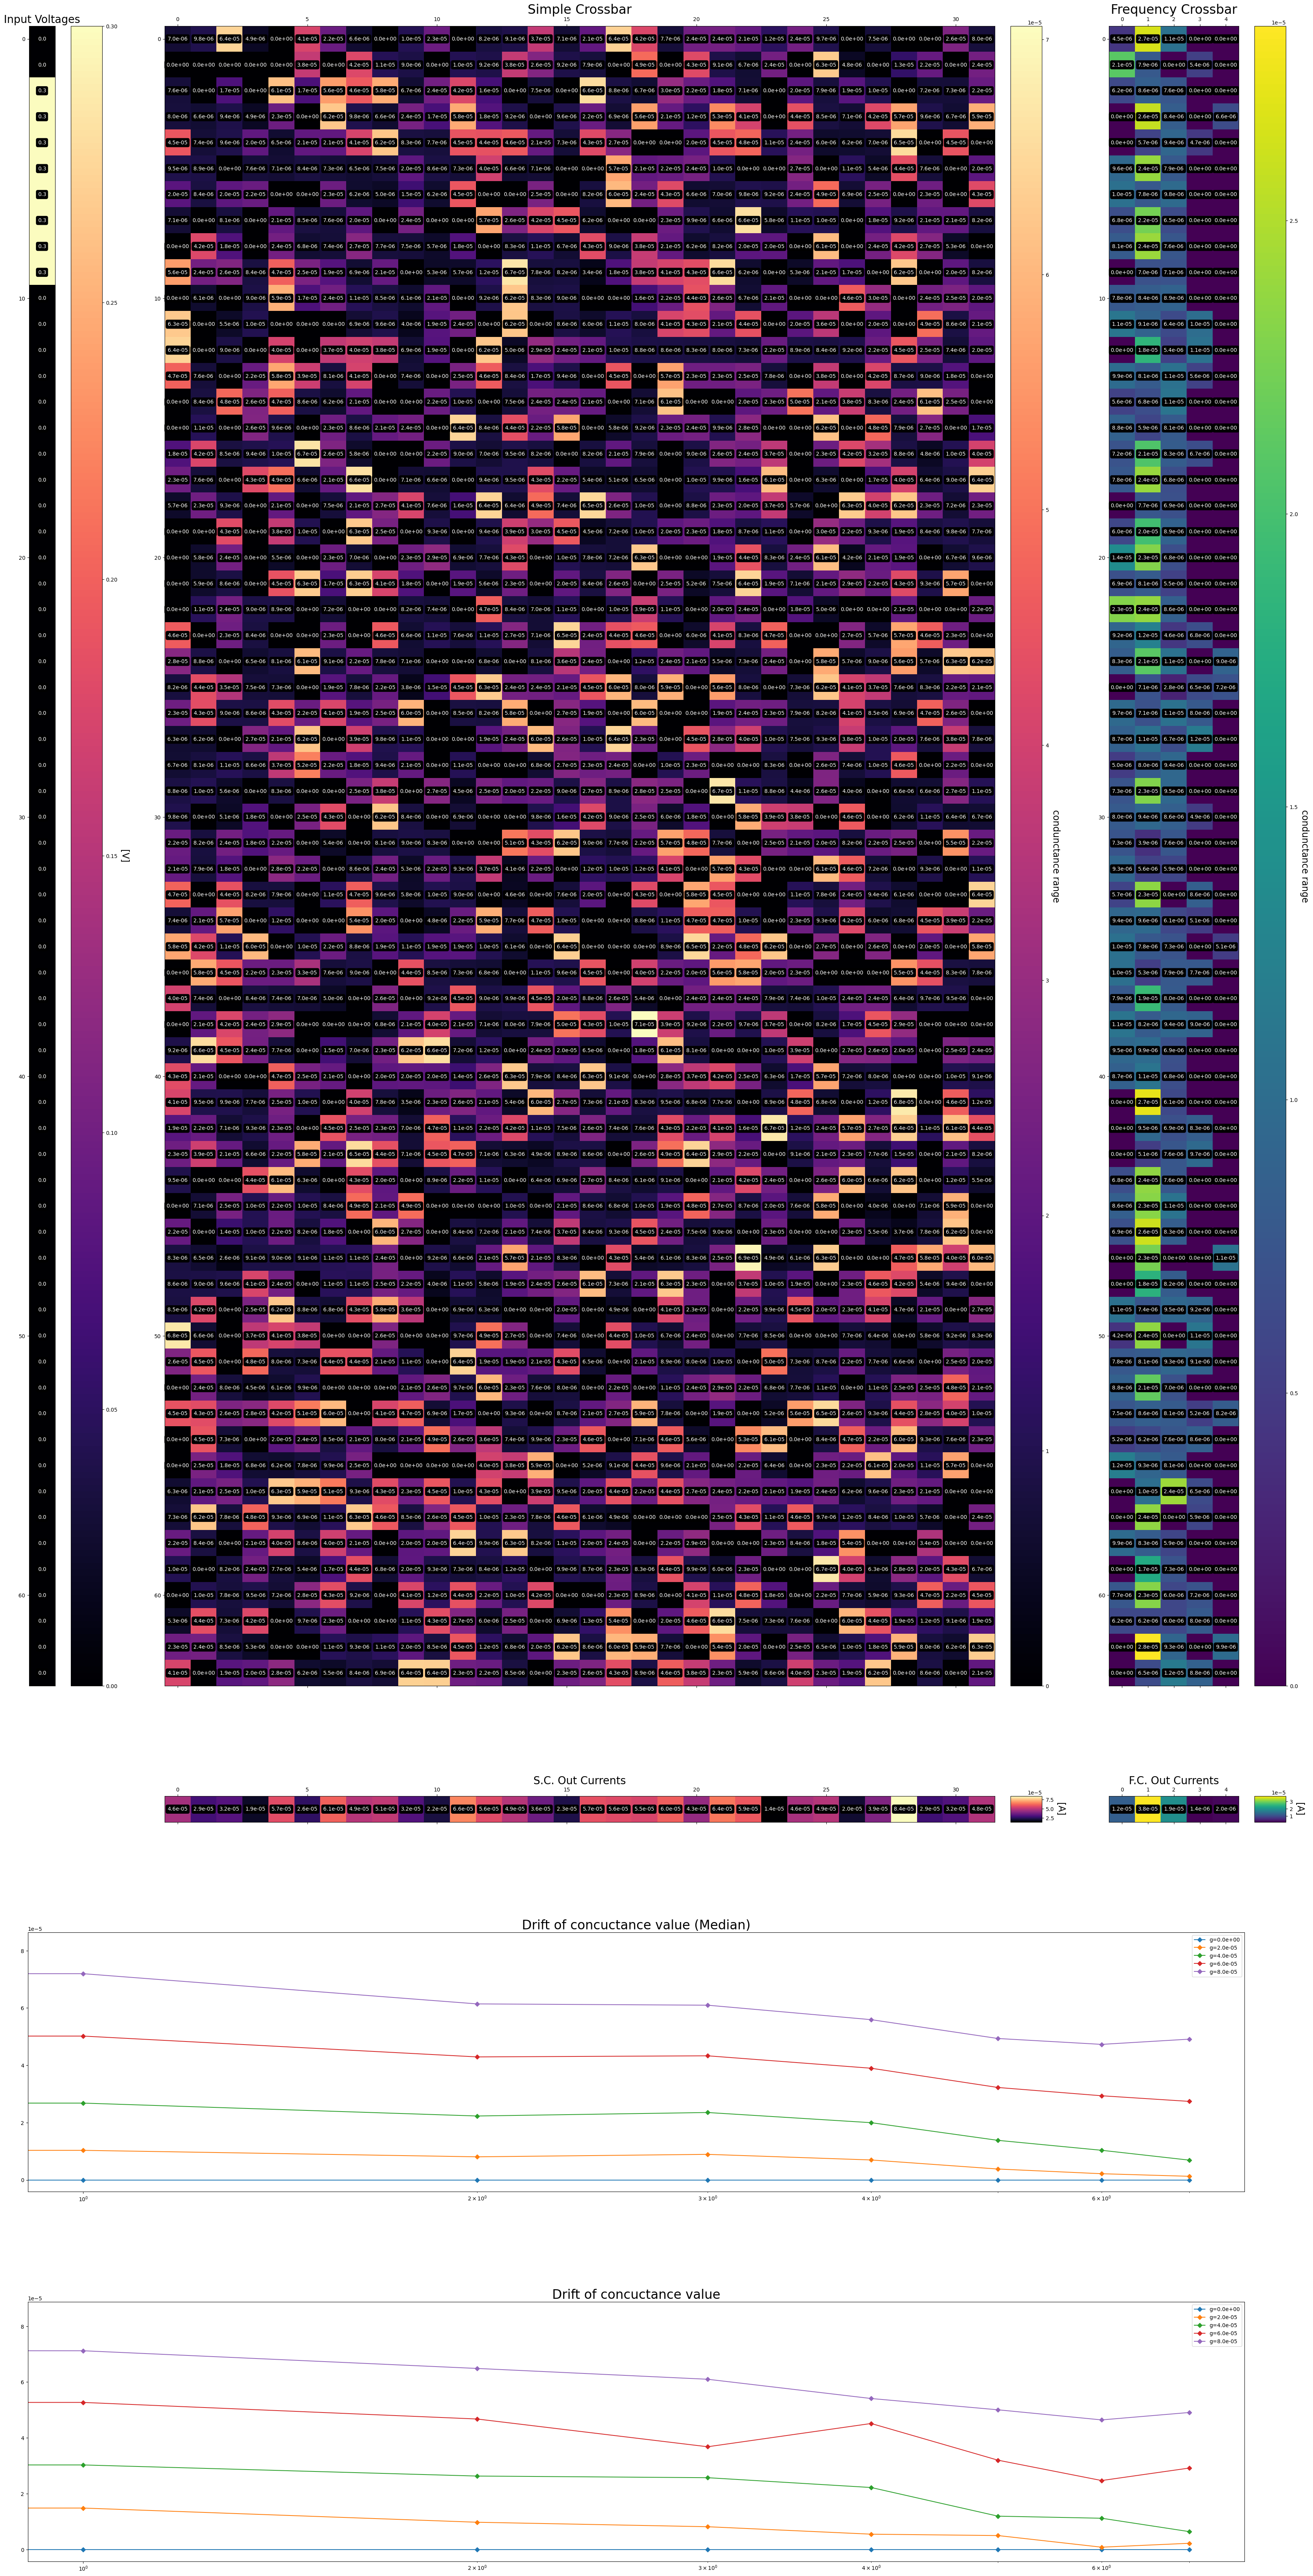

In [5]:
# Now also consider the drift of the conductances 

AVAILABLE_MODELS = ["IBM", "EXPERIMENTAL"]
CHOSEN_MODEL = AVAILABLE_MODELS[1]

# 1. IBM model
t_values = [1e-3,0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200,5000]
t_c = 1e-3
t = t_values[-1]
# 2. experimental data
drifter = CustomDrifter('../data/matlab/4bit.mat')
types = drifter.expose_types()
chosen_type = types[2]
print(types)
print("Chosen type: ", chosen_type)


g_values = np.linspace(0, max_g, n_levels)
print("The g_values are: ", g_values)

# compute the drift of the conductances
simple_crossbar_drift = np.zeros((N,M))
for i in range(N):
    for j in range(M):
        #quant_ij = random.randint(0, n_levels-1)
        simple_crossbar_drift[i,j] = g_drift_IBM(simple_crossbar[i,j], t_c, t) if CHOSEN_MODEL == "IBM" else drifter(simple_crossbar[i,j], chosen_type, n_levels, max_g)
        if simple_crossbar_drift[i,j] < 0.:
            ValueError("The conductance value should be positive")

frequency_crossbar_drift = np.zeros((N,n_levels))
for i in range(N):
    for j in range(n_levels):
        frequency_crossbar_drift[i,j] = g_drift_IBM(frequency_crossbar[i,j], t_c, t) if CHOSEN_MODEL == "IBM" else drifter(frequency_crossbar[i,j], chosen_type, n_levels, max_g)

quantized_frequency_crossbar_drift = np.zeros((N,n_levels))
for i in range(N):
    for j in range(n_levels):
        quantized_frequency_crossbar_drift[i,j] = g_drift_IBM(quantized_frequency_crossbar[i,j], t_c, t) if CHOSEN_MODEL == "IBM" else drifter(quantized_frequency_crossbar[i,j], chosen_type, n_levels, max_g)



currents_drift = np.zeros(M)
for i in range(M):
    currents_drift[i] += np.dot(simple_crossbar_drift[:,i], voltages)
    if currents_drift[i] < 0.:
        ValueError("The current value should be positive")
print("Currents on the drifted SIMPLE crossbar for the chosen input voltages ([0:10]): ", currents_drift[:10])

currents_drift_freq = np.zeros(n_levels)
for i in range(n_levels):
    currents_drift_freq[i] += np.dot(frequency_crossbar_drift[:,i], voltages)
print("Currents on the drifted FREQUENCY crossbar for the chosen input voltages ([0:10]): ", currents_drift_freq[:10])

currents_drift_quantized_freq = np.zeros(n_levels)
for i in range(n_levels):
    currents_drift_quantized_freq[i] += np.dot(quantized_frequency_crossbar_drift[:,i], voltages)
print("Currents on the drifted QUANTIZED FREQUENCY crossbar for the chosen input voltages ([0:10]): ", currents_drift_quantized_freq[:10])

# ============================================================================= PLOTTING =============================================================================
figsize = 1 *np.array(simple_crossbar_drift.shape) + 2
figsize[-1] += frequency_crossbar_drift.shape[-1] + 2
figsize[0] += 20
fig, axs = plt.subplots(4, 3, figsize=figsize[::-1], gridspec_kw={'width_ratios': [1, simple_crossbar_drift.shape[-1], frequency_crossbar_drift.shape[-1]],
                                                                    'height_ratios': [simple_crossbar_drift.shape[0], 1 ,10,10]  
                                                                  })

# Simple Crossbar
im = axs[0,1].matshow(simple_crossbar_drift, cmap="magma",origin='upper' )
for (i,j), z in np.ndenumerate(simple_crossbar_drift):
    axs[0,1].text(j, i, '{:.1e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = simple_crossbar_drift.shape[0]/simple_crossbar_drift.shape[1]
cax = fig.add_axes([axs[0,1].get_position().x1+0.01,axs[0,1].get_position().y0,0.02,axs[0,1].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("condunctance range", rotation=-90, va="bottom", fontsize=17)
axs[0,1].set_title("Simple Crossbar", fontsize=24)

# Frequency Crossbar
im = axs[0,2].matshow(frequency_crossbar_drift, cmap="viridis",origin='upper' )
for (i,j), z in np.ndenumerate(frequency_crossbar_drift):
    axs[0,2].text(j, i, '{:.1e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = frequency_crossbar_drift.shape[0]/frequency_crossbar_drift.shape[1]
cax = fig.add_axes([axs[0,2].get_position().x1+0.01,axs[0,2].get_position().y0,0.02,axs[0,2].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("condunctance range", rotation=-90, va="bottom", fontsize=17)    
axs[0,2].set_title("Frequency Crossbar", fontsize=24)

# Voltage inputs
# Input voltages
im = axs[0,0].matshow(voltages.reshape(-1,1), cmap="magma",origin='upper' )
for i, z in enumerate(voltages):
    axs[0,0].text(0, i, '{:0.1f}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = 1/voltages.shape[0]
cax = fig.add_axes([axs[0,0].get_position().x1+0.01,axs[0,0].get_position().y0,0.02,axs[0,0].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("[V]", rotation=-90, va="bottom", fontsize=17)
axs[0,0].set_xticks([])
axs[0,0].set_title("Input Voltages", fontsize=20)

# Simpre crossbar outputs
im = axs[1,1].matshow(currents_drift.reshape(1,-1), cmap="magma",origin='upper' )
for i, z in enumerate(currents_drift):
    axs[1,1].text(i, 0, '{:0.1e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = currents_drift.shape[0]/1
cax = fig.add_axes([axs[1,1].get_position().x1+0.01,axs[1,1].get_position().y0,0.02,axs[1,1].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("[A]", rotation=-90, va="bottom", fontsize=17)
axs[1,1].set_yticks([])
axs[1,1].set_title("S.C. Out Currents", fontsize=20)

# Frequency crossbar outputs
im = axs[1,2].matshow(currents_drift_freq.reshape(1,-1), cmap="viridis",origin='upper' )
for i, z in enumerate(currents_drift_freq):
    axs[1,2].text(i, 0, '{:0.1e}'.format(z), ha='center', va='center', color='white',
        bbox=dict(boxstyle='round', facecolor='black', edgecolor='black'))
im_ratio = currents_drift_freq.shape[0]/1
cax = fig.add_axes([axs[1,2].get_position().x1+0.01,axs[1,2].get_position().y0,0.02,axs[1,2].get_position().height])
cbar = plt.colorbar(im, cax=cax)
cbar.ax.set_ylabel("[A]", rotation=-90, va="bottom", fontsize=17)
axs[1,2].set_yticks([])
axs[1,2].set_title("F.C. Out Currents", fontsize=20)

# delete the axes for axs[1,0]
axs[1,0].axis('off')


# Plot the trend for the median drift contribution on log scale
gs = axs[2, 0].get_gridspec()
# remove the axes for the other plots
for i in range(2,4):
    for ax in axs[i,:]:
        ax.remove()
axbig1 = fig.add_subplot(gs[2,:])
axbig2 = fig.add_subplot(gs[3,:])

# Plot the trend for the median drift contribution on log scale
for g in g_values:
    drift_values = [g_drift_median_IBM(g, t_c, t) for t in t_values] if CHOSEN_MODEL == "IBM" else [drifter.g_drift_custom(g, t, n_levels, max_g, median=True, std=False) for t in types]
    axbig1.plot(t_values, drift_values, label="g={:0.1e}".format(g), marker='D') if CHOSEN_MODEL == "IBM" else axbig1.plot(types, drift_values, label="g={:0.1e}".format(g), marker='D')


axbig1.set_xscale('log')
axbig1.legend()
axbig1.set_title("Drift of concuctance value (Median)", fontsize=24)

# Plot the trend for the drift contribution on log scale
for g in g_values:
    drift_values = [g_drift_IBM(g, t_c, t) for t in t_values] if CHOSEN_MODEL == "IBM" else [drifter.g_drift_custom(g, t, n_levels, max_g, median=True, std=True) for t in types]
    axbig2.plot(t_values, drift_values, label="g={:0.1e}".format(g), marker='D') if CHOSEN_MODEL == "IBM" else axbig2.plot(types, drift_values, label="g={:0.1e}".format(g), marker='D')

axbig2.set_xscale('log')
axbig2.legend()
axbig2.set_title("Drift of concuctance value", fontsize=24)

plt.show()


## IBM drift correction:

IBM drift correction uses a standardized vector of input voltages (say, Vdd/2) to read the currets at time t = 0. The sum of a fixed number of there collected currents is then stored and used to correct the drift in the current measurements. This is done by measuring the current at a later time t = t1 and dividing the current by the sum of the currents collected at time t = 0.

IBM correction factor:  0.6062191066872271
Indexes of the most significant terms:  [28 10 26  9  2  5  3 13 30 22]
Values of the most significant terms:  [2.45423741e-05 1.75486824e-05 1.43076857e-05 1.35297773e-05
 1.24653629e-05 1.10172889e-05 1.06312807e-05 8.55601955e-06
 8.00258114e-06 7.68804818e-06]
MSE:  7.237472783843553e-11
Difference between the sums:  4.346020296726683e-09
MSE_ref:  8.240166319826909e-08


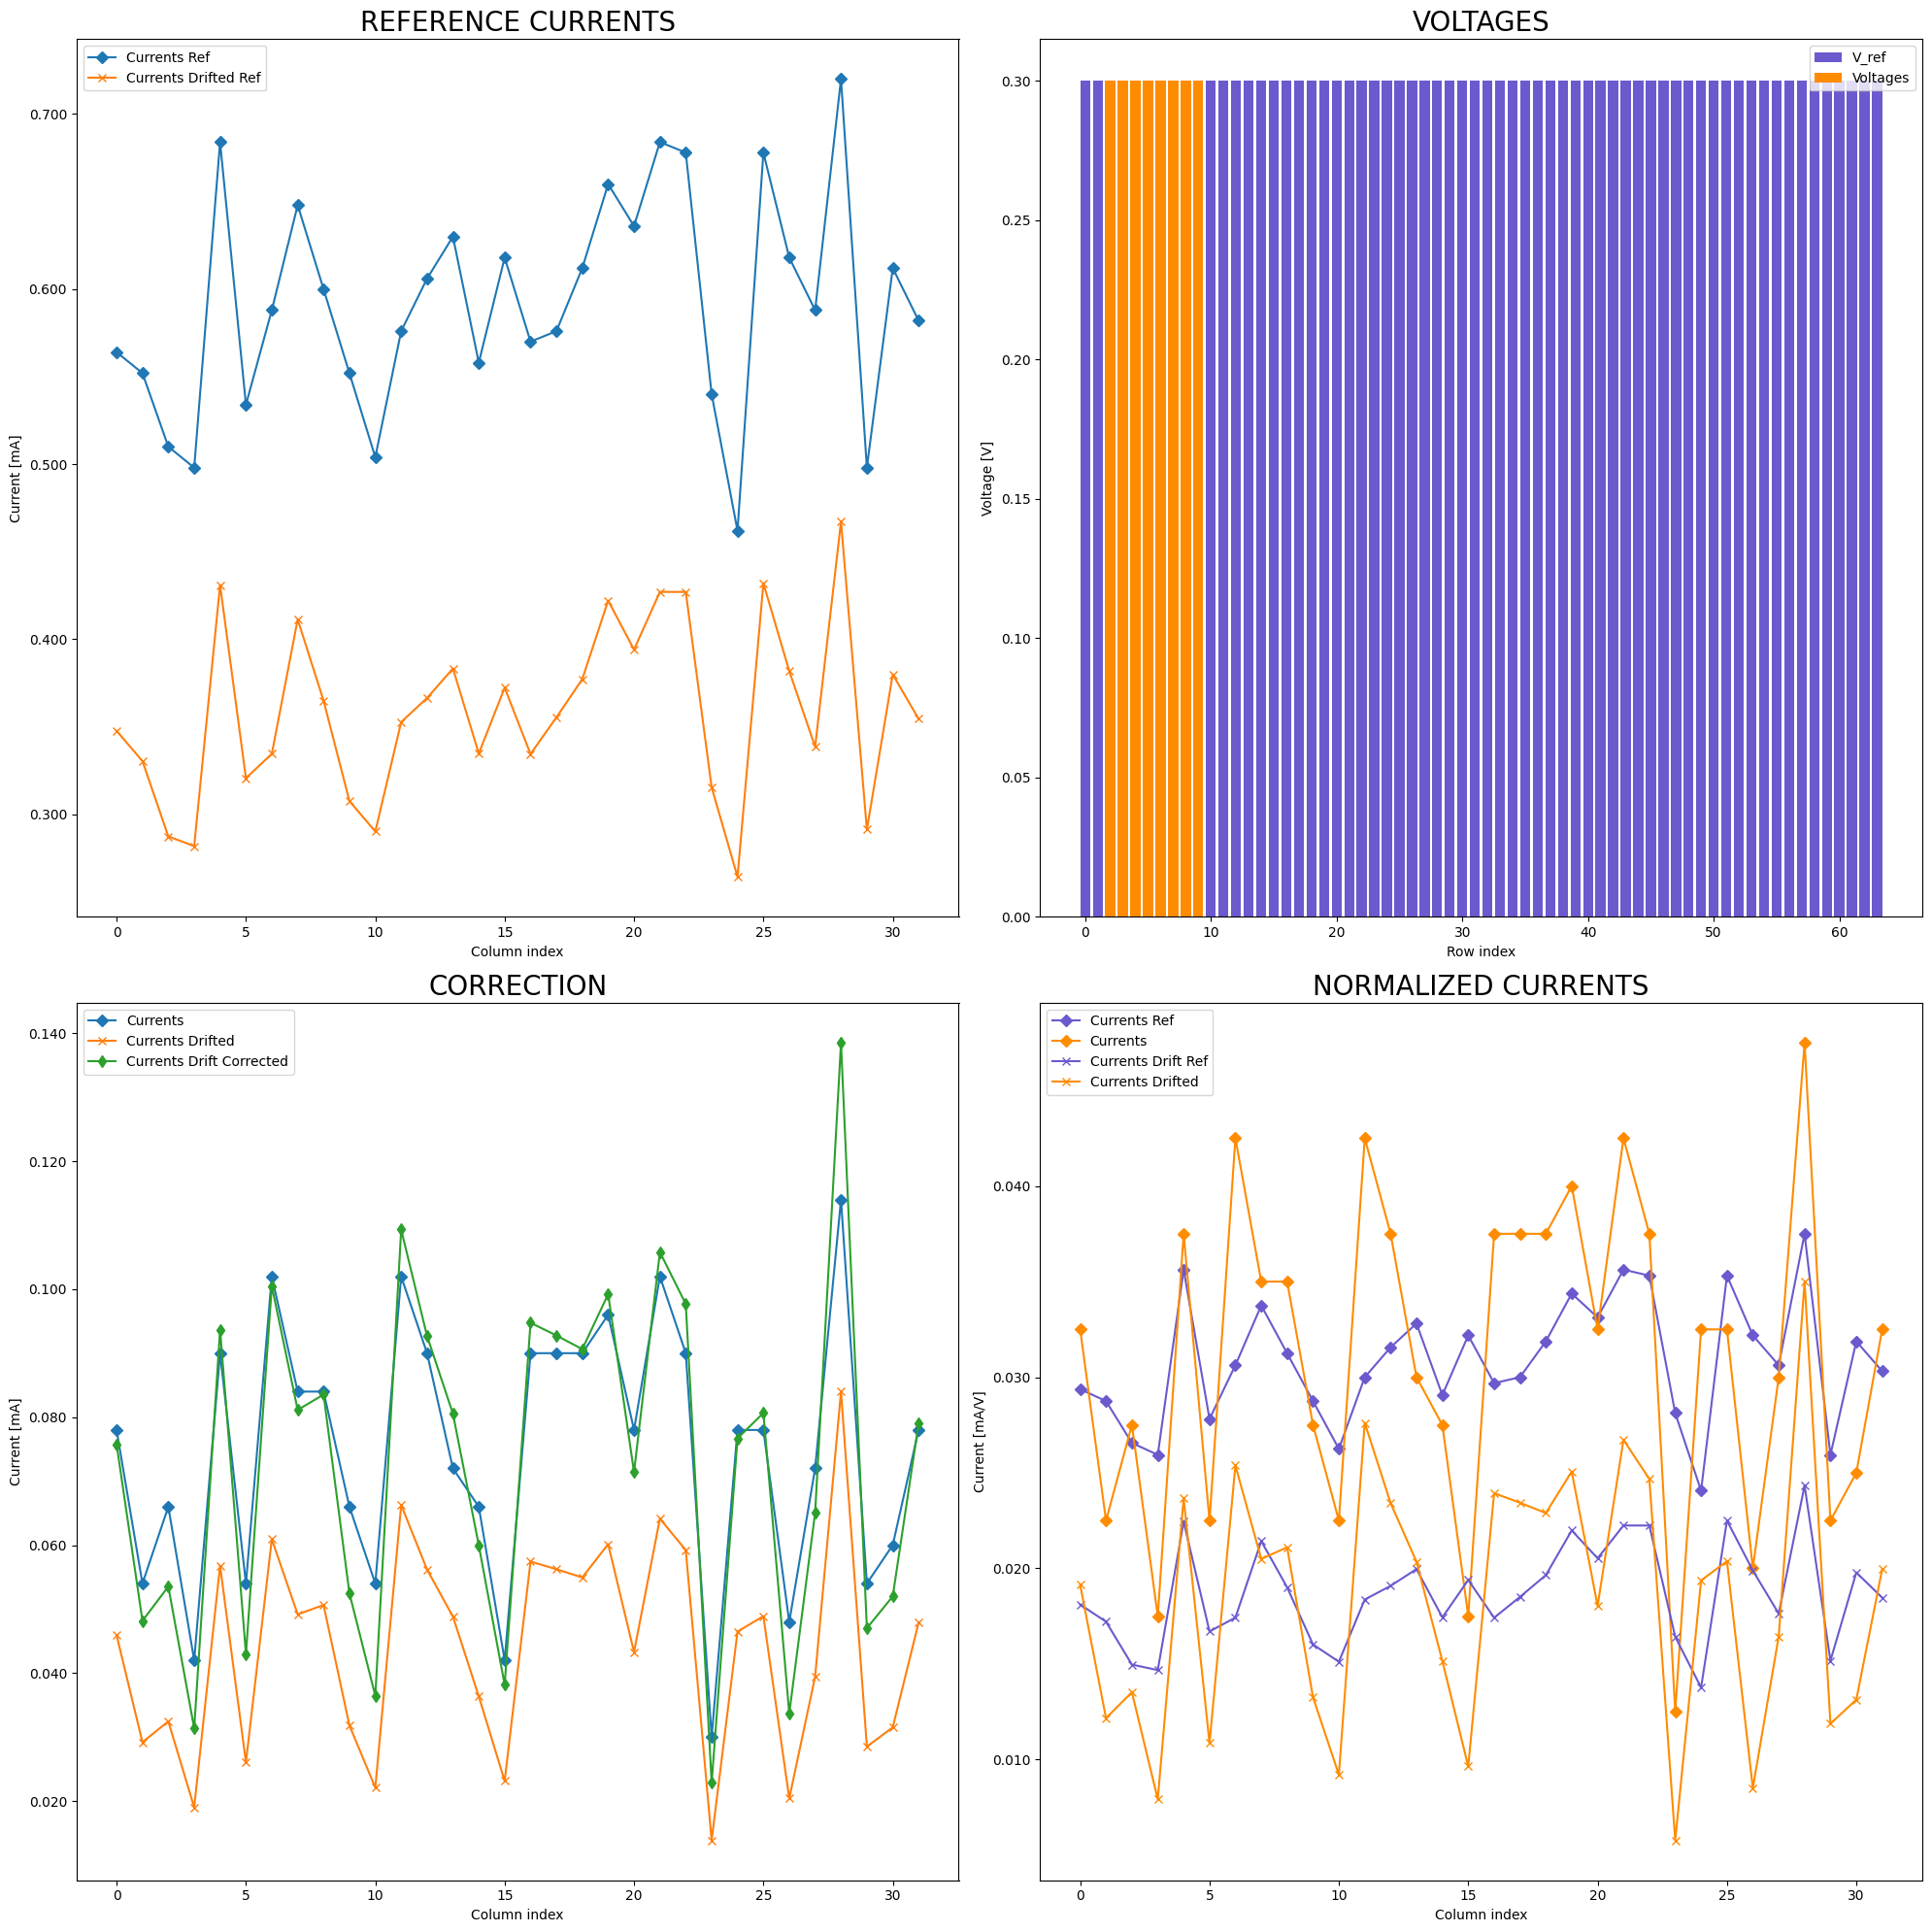

In [6]:
# Employ the IBM correction, compute the currents on the drifted crossbar usin the reference voltages
currents_drift_ref = np.zeros(M)
for i in range(M):
    currents_drift_ref[i] = np.dot(simple_crossbar_drift[:,i], Vref)


ideal_IBM_correction = sum(currents_drift)/sum(currents)
ref_IBM_correction = sum(currents_drift_ref)/sum(currents_ref)
print("IBM correction factor: ", ref_IBM_correction)

# correct the currents
currents_drift_corrected_IBM = currents_drift/ref_IBM_correction


# =========== PLOT REFERENCE CURRENTS ===========
fig, ax = plt.subplots(2,2, figsize=(20,20))
ax[0,0].plot(currents_ref, label="Currents Ref", marker='D')
ax[0,0].plot(currents_drift_ref, label="Currents Drifted Ref", marker='x')
ax[0,0].set_xlabel("Column index")
ax[0,0].set_ylabel(r"Current [mA]")
ax[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.3f}".format(x*1e3)))
ax[0,0].legend()
ax[0,0].set_title("REFERENCE CURRENTS", fontsize=20)

# =========== PLOT CORRECTION EFFECTS ===========
# Plot currents and currents_drift_corrected_IBM
ax[1,0].plot(currents, label="Currents", marker='D')
ax[1,0].plot(currents_drift, label="Currents Drifted", marker='x')
ax[1,0].plot(currents_drift_corrected_IBM, label="Currents Drift Corrected", marker='d')
ax[1,0].set_xlabel("Column index")
ax[1,0].set_ylabel(r"Current [mA]")
ax[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.3f}".format(x*1e3)))
ax[1,0].legend()
ax[1,0].set_title("CORRECTION", fontsize=20)


# =========== PLOT V_ref - voltages ===========
ax[0,1].bar(np.arange(N), Vref, label="V_ref", color='slateblue')
ax[0,1].bar(np.arange(N), voltages, label="Voltages", color='darkorange')
ax[0,1].set_xlabel("Row index")
ax[0,1].set_ylabel("Voltage [V]")
ax[0,1].legend()
ax[0,1].set_title("VOLTAGES", fontsize=20)

# =========== PLOT currents_ref - currents  ===========
# normalize the currents by the sum of voltage signals
# applied to the crossbar to obtain those
ax[1,1].plot(currents_ref/sum(Vref), label="Currents Ref", marker='D', color='slateblue')
ax[1,1].plot(currents/sum(voltages), label="Currents", marker='D', color= 'darkorange')
ax[1,1].plot(currents_drift_ref/sum(Vref), label="Currents Drift Ref", marker='x', color='slateblue')
ax[1,1].plot(currents_drift/sum(voltages), label="Currents Drifted", marker='x', color='darkorange')
ax[1,1].set_xlabel("Column index")
ax[1,1].set_ylabel(r"Current [mA/V]")
ax[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.3f}".format(x*1e3)))
ax[1,1].legend()
ax[1,1].set_title("NORMALIZED CURRENTS", fontsize=20)



plt.tight_layout()

# compute the MSE
MSE = compute_MSE(currents, currents_drift_corrected_IBM, verbose=True)
SUM_DIFF_SQR = compute_SUM_DIFF_SQR(currents, currents_drift_corrected_IBM, verbose=True)

# compute MSE error between the currents vs currents_ref and currents vs currents_approx
MSE_ref = compute_MSE(currents, currents_drift_ref, verbose=False)

print("MSE_ref: ", MSE_ref)


## Drift Compensation with Frequency Matrix

The IBM drift compensation does not take into account the fact that, at inference time, the input voltages may vary largely from the standardized, reference value. This does not constitue a problem as long as the drift affects the condunctance values 'equally' (i.e. the conductance values shift, in a mean sense, by the same amount). Otherwise, there may be some input vectors that only set on certain word lines. On these rows, the distribution of the conductances may be different from the one represented by the whole of the tile. This may lead to a drift that is dominated dy the mean values of the drift for the conductance values associated to a certain level, rather than others.

### Notes

While considering only the mean shifts for the conductance values and using the frequency matrix drift compensation method allows to dump the error on the <b>difference of the cumulative currents in readout</b> but does not provide any kind of guarantee on the MSE error.
Furthermore, once the variance of the drift phenomenon is accounted for, the state-specific compensation proposed by IBM (state-specific in the sense that it is computed out of the currents of the same crossbar on which the correction will later be applied) tends to be as effective (if not more) - and at a lower cost - than the frequency matrix drift compensation method.

This highlights the need for compensation methods that take into consideration directly the drift on the very same conductace values that will determine the output currents: reasoning in terms of median values, using reference tiles, does not take into account the specific variations of the conductance values that will also influence the readout.

Correction factor:  0.6013085164776931
Indexes of the most significant terms:  [28 10 26  9  2  5  3 13 22 11]
Values of the most significant terms:  [2.56737814e-05 1.72510024e-05 1.40325372e-05 1.31012788e-05
 1.20281719e-05 1.06662703e-05 1.03751078e-05 9.21388085e-06
 8.48581831e-06 8.21265578e-06]
MSE:  7.348921928814422e-11
Difference between the sums:  2.2007457610212347e-09


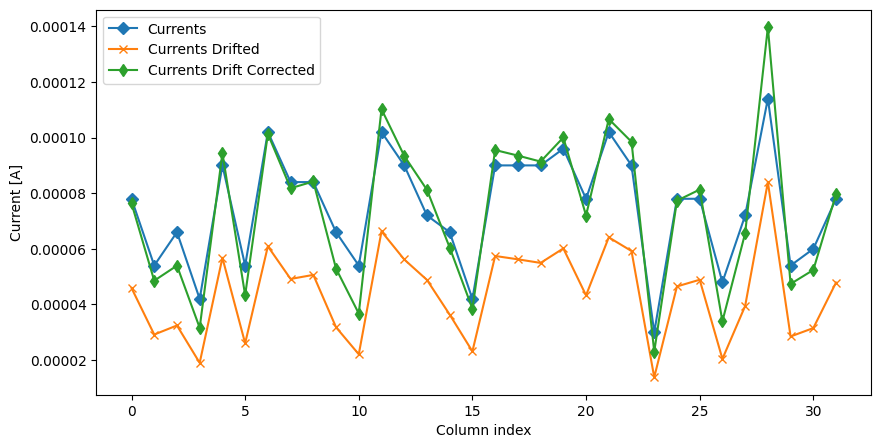

In [7]:


# appling IBM correction to the frequency crossbar is useless, since the correction factor is the same
# for all the conductance levels (for all the bitlines)

# =============== IDEAL WEIGHTS ===============
# consider digitally stored weights
weights = currents_freq
# =============== IDEAL WEIGHTS ===============

# ============== DRIFTED WEIGHTS ==============
# consider the drifted weights
#weights = currents_drift_quantized_freq
# ============== DRIFTED WEIGHTS ===#==========


# Now perform the correction using the frequency crossbar
n_samples_per_level = 250
reference_tile = np.zeros((n_levels,n_samples_per_level))
for i in range(n_levels):
    reference_tile[i] = [g_drift_IBM(g_values[i], t_c, t) if CHOSEN_MODEL == "IBM" else drifter(g_values[i], chosen_type, n_levels, max_g) for _ in range(n_samples_per_level)]
# compute the means for rows, then divide by the orginal g value to obtain the drift coefficients
drift_mean_values = np.mean(reference_tile, axis=1)
#print("Mean values for the drifted conductance values: ", mean_values)


#drift_coefficients = drift_mean_values/g_values
#print("Drift coefficients: ", drift_coefficients)
#print("Ideal drift coefficients: ", ideal_drift_coefficients_median)


# Compute the correction factor
I_o = g_values*weights
I_t = drift_mean_values*weights
#print("w:", w)
FREQ_correction = np.sum(I_t)/np.sum(I_o)
print("Correction factor: ", FREQ_correction)

# correct the currents
currents_drift_corrected_freq = currents_drift/FREQ_correction

# compute the error using the ideal currents and MSE
MSE = compute_MSE(currents, currents_drift_corrected_freq, verbose=True)
SUM_DIFF_SQR = compute_SUM_DIFF_SQR(currents, currents_drift_corrected_freq, verbose=True)

# Plot currents and currents_drift_corrected_freq
fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.plot(currents, label="Currents", marker='D')
ax.plot(currents_drift, label="Currents Drifted", marker='x')
ax.plot(currents_drift_corrected_freq, label="Currents Drift Corrected", marker='d')
ax.set_xlabel("Column index")
ax.set_ylabel("Current [A]")
legend=ax.legend()



## MSE Drift Compensation

Correction factor:  0.6092304966817982
Indexes of the most significant terms:  [28 10 26  9  2  5  3 30 13 23]
Values of the most significant terms:  [2.38575675e-05 1.77288591e-05 1.44742248e-05 1.37891345e-05
 1.27299814e-05 1.12297499e-05 1.07863344e-05 8.25960128e-06
 8.15783596e-06 7.26303869e-06]
MSE:  7.208990134189252e-11
Difference between the sums:  5.99569787568459e-09


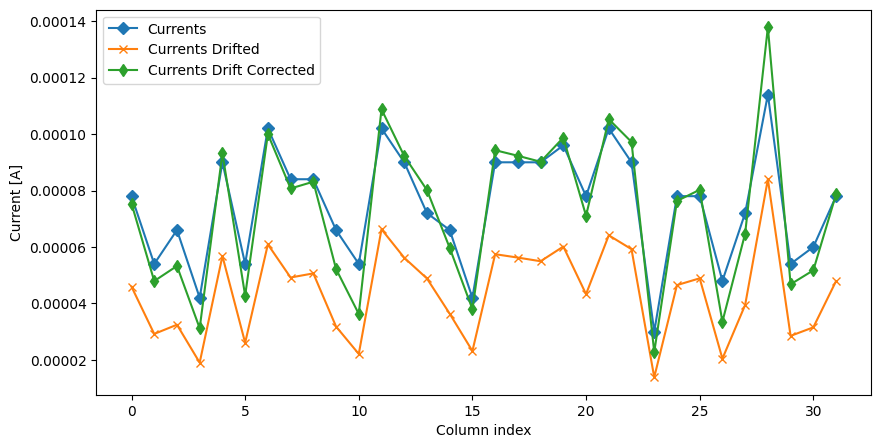

In [8]:
ideal_correction_for_MSE = np.dot(currents_drift, currents_drift)/ np.dot(currents, currents_drift)

ref_correction_for_MSE = np.dot(currents_drift_ref, currents_drift_ref)/ np.dot(currents_ref, currents_drift_ref)

# estimate the error for the ideal correction
corrected_currents_for_MSE = currents_drift/ref_correction_for_MSE

# ============================================

# ============================================


print("Correction factor: ", ref_correction_for_MSE)



MSE = compute_MSE(currents, corrected_currents_for_MSE,verbose=True)
SUM_DIFF_SQR = compute_SUM_DIFF_SQR(currents, corrected_currents_for_MSE, verbose = True)

# Plot currents and currents_drift_corrected_freq
fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.plot(currents, label="Currents", marker='D')
ax.plot(currents_drift, label="Currents Drifted", marker='x')
ax.plot(corrected_currents_for_MSE, label="Currents Drift Corrected", marker='d')
ax.set_xlabel("Column index")
ax.set_ylabel("Current [A]")
legend=ax.legend()


## Comparison

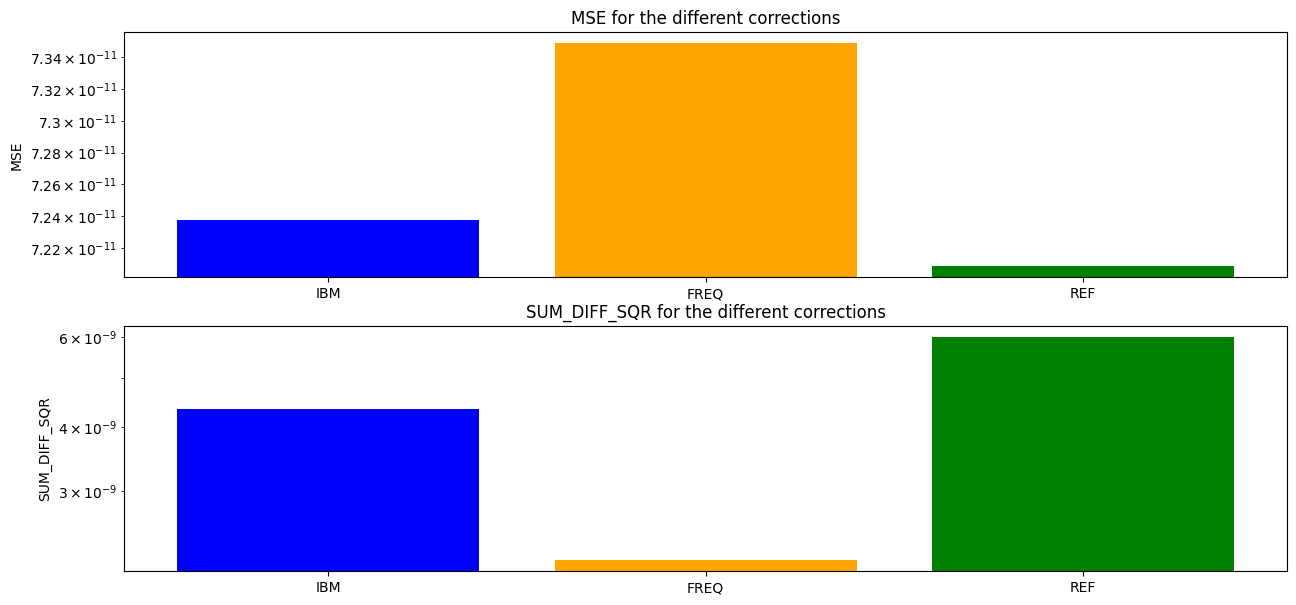

In [9]:


# plot the difference between the MSE errors for the 3 corrections
fig, ax = plt.subplots(2,1, figsize=(15,7))

ax[0].bar(["IBM", "FREQ", "REF"], [compute_MSE(currents, currents_drift_corrected_IBM, verbose=False), compute_MSE(currents, currents_drift_corrected_freq, verbose=False), compute_MSE(currents, corrected_currents_for_MSE, verbose=False)], color = ['blue', 'orange', 'green'])
ax[0].set_ylabel("MSE")
ax[0].set_title("MSE for the different corrections")
ax[0].set_yscale('log')


ax[1].bar(["IBM", "FREQ", "REF"], [compute_SUM_DIFF_SQR(currents, currents_drift_corrected_IBM, verbose=False), compute_SUM_DIFF_SQR(currents, currents_drift_corrected_freq, verbose=False), compute_SUM_DIFF_SQR(currents, corrected_currents_for_MSE, verbose=False)], color = ['blue', 'orange', 'green'])
ax[1].set_ylabel("SUM_DIFF_SQR")
ax[1].set_title("SUM_DIFF_SQR for the different corrections")
ax[1].set_yscale('log')

## Statistic analysis


In [10]:
from scipy.optimize import curve_fit
from scipy import stats

# -- 1. Get a random set of input vectors
set_cardinality =20000
volt_set = []
for i in range(set_cardinality):
    # draw a random input vector of N elements
    while True:
        inputs = np.clip(abs(np.random.normal(0,max_input/2, N)),0,max_input)
        voltages = DAC_quantizer(inputs, bits, Vdd, max_input)
        if np.sum(voltages) != 0:
            break
    volt_set.append(voltages)

IBM_MSEs = np.zeros((len(types), set_cardinality))
FREQ_dig_MSEs = np.zeros((len(types), set_cardinality))
FREQ_analog_MSEs = np.zeros((len(types), set_cardinality))
MSE_MSEs = np.zeros((len(types), set_cardinality))
WEIGHTED_MSEs = np.zeros((len(types), set_cardinality))


IBM_FREQ_DIG_comparisons = np.zeros((len(types), set_cardinality))
IBM_FREQ_ANALOG_comparisons = np.zeros((len(types), set_cardinality))
IBM_MSE_comparisons = np.zeros((len(types), set_cardinality))
IBM_WEIGHTED_comparisons = np.zeros((len(types), set_cardinality))
for drift_noise in types:
    print("Drift noise type: ", drift_noise)
    # -- 2. Given the type, drift the conductances of the simple crossbar accordingly
    simple_crossbar_drift = np.zeros((N,M))
    for i in range(N):
        for j in range(M):
            simple_crossbar_drift[i,j] = g_drift_IBM(simple_crossbar[i,j], t_c, t) if CHOSEN_MODEL == "IBM" else drifter(simple_crossbar[i,j], drift_noise, n_levels, max_g)

    # drift the frequency crossbar
    frequency_crossbar_drift = np.zeros((N,n_levels))
    for i in range(N):
        for j in range(n_levels):
            frequency_crossbar_drift[i,j] = g_drift_IBM(frequency_crossbar[i,j], t_c, t) if CHOSEN_MODEL == "IBM" else drifter(frequency_crossbar[i,j], drift_noise, n_levels, max_g)

    # drift the quantized frequency crossbar
    quantized_frequency_crossbar_drift = np.zeros((N,n_levels))
    for i in range(N):
        for j in range(n_levels):
            quantized_frequency_crossbar_drift[i,j] = g_drift_IBM(quantized_frequency_crossbar[i,j], t_c, t) if CHOSEN_MODEL == "IBM" else drifter(quantized_frequency_crossbar[i,j], drift_noise, n_levels, max_g)
    
    # Also use a new reference tile for each new drift type
    reference_tile = np.zeros((n_levels,n_samples_per_level))
    for i in range(n_levels):
        reference_tile[i] = [g_drift_IBM(g_values[i], t_c, t) if CHOSEN_MODEL == "IBM" else drifter(g_values[i], drift_noise, n_levels, max_g) for _ in range(n_samples_per_level)]
    # compute the means for rows, then divide by the orginal g value to obtain the drift coefficients
    drift_mean_values = np.mean(reference_tile, axis=1)

    
    # IBM correction factor can be computed only once since we do not change the reference voltages
    currents_drift_ref = np.zeros(M)
    for i in range(M):
        currents_drift_ref[i] = np.dot(simple_crossbar_drift[:,i], Vref)
    IBM_correction = sum(currents_drift_ref)/sum(currents_ref)
    print("IBM correction factor: ", IBM_correction)

    # MSE correction factor can be computed only once since we do not change the reference voltages
    MSE_correction = np.dot(currents_drift_ref, currents_drift_ref)/ np.dot(currents_ref, currents_drift_ref)
    print("MSE correction factor: ", MSE_correction)

    # WEIGHTED correction
    # compute weighted linear regression on the drift mean values
    def func(x, a, b):
        return a*x + b # plain linear function to be fitted
    # ================== GUASSIAN WEIGHTS ==================
    w = stats.norm.pdf(np.linspace(0, 40, n_levels), 0, 14)
    # ================== GUASSIAN WEIGHTS ==================
    # ================== HISTOGRAM WEIGHTS ==================
    # w = np.histogram(simple_crossbar, bins = n_levels)[0]
    # # normalize the weights
    # w = w/np.sum(w)
    # ================== HISTOGRAM WEIGHTS ==================
    w = (w.max() - w) + w.min() # reverse the weights
    p0= 1,0
    print("Weights: ", w)
    print("Drift mean values: ", drift_mean_values)
    print("G values: ", g_values)
    popt, _ = curve_fit(func, g_values, drift_mean_values, p0, sigma = w, absolute_sigma = False)
    slope = popt[0]
    intercept = popt[1]
    print("Weighted correction factor: ", slope)


    # -- 3. Evaluate the corrections for each noise type, for each voltage input vector
    for volt_index, voltages in enumerate(volt_set):

        # compute the currents on the simple crossbar
        currents = np.zeros(M)
        for i in range(M):
            currents[i] = np.dot(simple_crossbar[:,i], voltages)
    

        # Compute the currents on the drifted crossbar
        currents_drift = np.zeros(M)
        for i in range(M):
            currents_drift[i] += np.dot(simple_crossbar_drift[:,i], voltages)

        # Perform the corrections

        # =========================
        # 1. IBM correction ( need to recompute the reference currents after the drift but not the ones at initialization)
        currents_drift_corrected_IBM = currents_drift/IBM_correction
        # =========================

        # =========================
        # 2. Frequency correction ( need to recompute the drift coefficients - per type - and the weights)
        currents_freq = np.zeros(n_levels)
        for i in range(n_levels):
            currents_freq[i] = np.dot(frequency_crossbar[:,i], voltages)

        currents_drift_freq = np.zeros(n_levels)
        for i in range(n_levels):
            currents_drift_freq[i] += np.dot(quantized_frequency_crossbar_drift[:,i], voltages)
        # compute the correction factor using 'IDEAL' weights
        weights = currents_freq
        weights_quantized = currents_drift_freq
        I_o = g_values*weights
        I_o_quantized = g_values*weights_quantized
        I_t = drift_mean_values*weights
        I_t_quantized = drift_mean_values*weights_quantized
        FREQ_correction = np.sum(I_t)/np.sum(I_o)
        FREQ_correction_quantized = np.sum(I_t_quantized)/np.sum(I_o_quantized)
        currents_drift_corrected_freq = currents_drift/FREQ_correction
        currents_drift_corrected_quantized_freq = currents_drift/FREQ_correction_quantized
        # =========================

        # =========================
        # 3. MSE correction ( need to recompute the reference currents after the drift but not the ones at initialization)
        currents_drift_corrected_MSE = currents_drift/MSE_correction
        # =========================

        # =========================
        # 4. weighted correction
        currents_drift_corrected_weighted = currents_drift/slope
        # =========================

        # compute the error using the ideal currents and MSE
        mse_IBM = compute_MSE(currents, currents_drift_corrected_IBM, verbose = False)
        mse_FREQ_DIG = compute_MSE(currents, currents_drift_corrected_freq, verbose = False)
        mse_FREQ_ANALOG = compute_MSE(currents, currents_drift_corrected_quantized_freq, verbose = False)
        mse_MSE = compute_MSE(currents, currents_drift_corrected_MSE, verbose = False)
        mse_WEIGHTED = compute_MSE(currents, currents_drift_corrected_weighted, verbose = False)

        IBM_MSEs[types.index(drift_noise), volt_index] = mse_IBM
        FREQ_dig_MSEs[types.index(drift_noise), volt_index] = mse_FREQ_DIG
        FREQ_analog_MSEs[types.index(drift_noise), volt_index] = mse_FREQ_ANALOG
        MSE_MSEs[types.index(drift_noise), volt_index] = mse_MSE
        WEIGHTED_MSEs[types.index(drift_noise), volt_index] = mse_WEIGHTED

        # compute percentage difference on MSE values and store it
        IBM_FREQ_DIG_comparisons[types.index(drift_noise), volt_index] = (mse_IBM - mse_FREQ_DIG)/mse_IBM * 100
        IBM_FREQ_ANALOG_comparisons[types.index(drift_noise), volt_index] = (mse_IBM - mse_FREQ_ANALOG)/mse_IBM * 100
        IBM_MSE_comparisons[types.index(drift_noise), volt_index] = (mse_IBM - mse_MSE)/mse_IBM * 100
        IBM_WEIGHTED_comparisons[types.index(drift_noise), volt_index] = (mse_IBM - mse_WEIGHTED)/mse_IBM * 100
        

# Finally, compute the average percentage difference on MSE values
average_diff = np.mean(IBM_FREQ_DIG_comparisons, axis=1)
std_diff = np.std(IBM_FREQ_DIG_comparisons, axis=1)
print("Average  IBMvFREQ(dig): ", average_diff)
#print("Standard  for IBMvFREQ: ", std_diff)
average_diff = np.mean(IBM_MSE_comparisons, axis=1)
std_diff = np.std(IBM_MSE_comparisons, axis=1)
print("Average  IBMvMSE (ref values)", average_diff)
#print("Standard for IBMvMSE (ref values)", std_diff)
average_diff = np.mean(IBM_WEIGHTED_comparisons, axis=1)
std_diff = np.std(IBM_WEIGHTED_comparisons, axis=1)
print("Average  IBMvMSE (weighted)", average_diff)


# Plot 



Drift noise type:  Prog
IBM correction factor:  1.0522480054645875
MSE correction factor:  1.0519671660355596
Weights:  [0.00048101 0.00689721 0.01870561 0.02610824 0.02849588]
Drift mean values:  [0.00000000e+00 2.16411447e-05 4.19732714e-05 6.24690905e-05
 8.21105571e-05]
G values:  [0.e+00 2.e-05 4.e-05 6.e-05 8.e-05]
Weighted correction factor:  1.0512259881244113
Drift noise type:  1d,RT
IBM correction factor:  0.7243224912804539
MSE correction factor:  0.7274463090346801
Weights:  [0.00048101 0.00689721 0.01870561 0.02610824 0.02849588]
Drift mean values:  [0.00000000e+00 1.03461558e-05 2.68148893e-05 5.02912415e-05
 7.15973077e-05]
G values:  [0.e+00 2.e-05 4.e-05 6.e-05 8.e-05]
Weighted correction factor:  0.7231682656810804
Drift noise type:  30d,RT
IBM correction factor:  0.6051146183768814
MSE correction factor:  0.6080576659314028
Weights:  [0.00048101 0.00689721 0.01870561 0.02610824 0.02849588]
Drift mean values:  [0.00000000e+00 8.14630013e-06 2.20827900e-05 4.26341793e-

Text(0.5, 1.0, 'Average percentage difference on MSE values for each drift noise type')

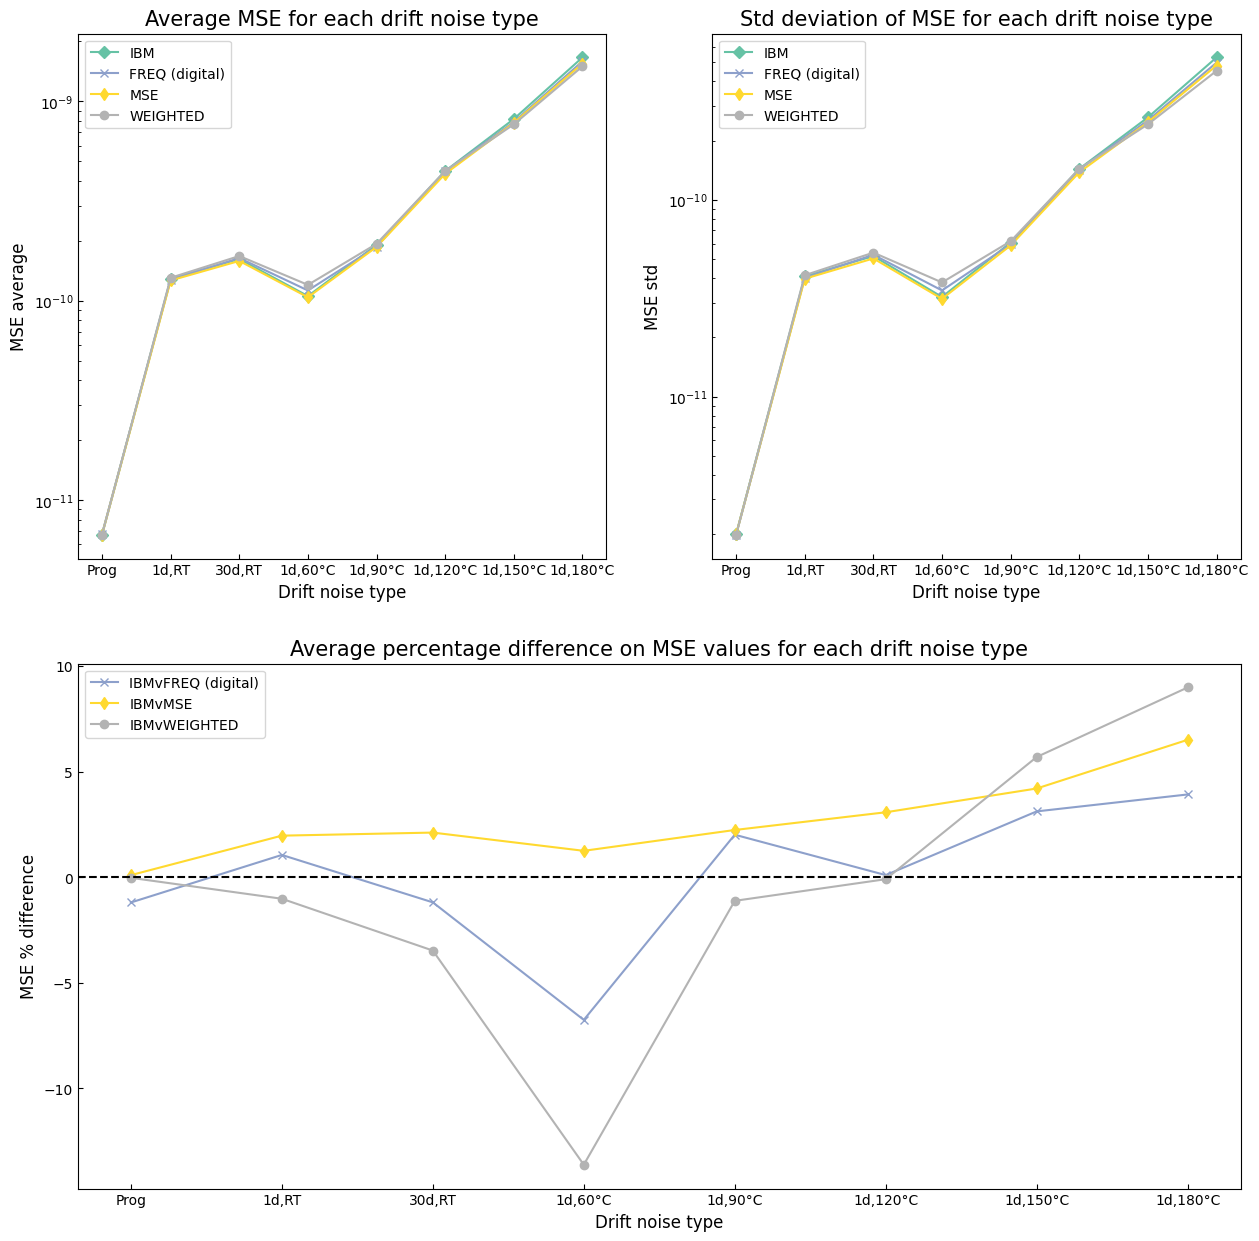

In [11]:
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
fig, ax = plt.subplots(2,2, figsize=(15,15))
colormap = "Set2"
colors = plt.get_cmap(colormap)(np.linspace(0, 1, 4))

# the first plot shows the average MSE error for each drift noise type, using a different color for each correction method
ax[0,0].plot(types, np.average(IBM_MSEs, axis=1), label="IBM", marker='D', color=colors[0])
ax[0,0].plot(types, np.average(FREQ_dig_MSEs, axis=1), label="FREQ (digital)", marker='x', color=colors[1])
#ax[0,0].plot(types, np.average(FREQ_analog_MSEs, axis=1), label="FREQ (analog)", marker='x', color=colors[1], linestyle='-.')
ax[0,0].plot(types, np.average(MSE_MSEs, axis=1), label="MSE", marker='d', color=colors[2])
ax[0,0].plot(types, np.average(WEIGHTED_MSEs, axis=1), label="WEIGHTED", marker='o', color=colors[3])
ax[0,0].set_xlabel("Drift noise type", fontsize=12)
ax[0,0].set_ylabel("MSE average", fontsize=12)
ax[0,0].legend()
# set log scale for the y axis
ax[0,0].set_yscale('log')
ax[0,0].set_title("Average MSE for each drift noise type", fontsize=15)

# the second plot shows the std deviation of the MSE error for each drift noise type, using a different color for each correction method
ax[0,1].plot(types, np.std(IBM_MSEs, axis=1), label="IBM", marker='D', color=colors[0])
ax[0,1].plot(types, np.std(FREQ_dig_MSEs, axis=1), label="FREQ (digital)", marker='x', color=colors[1])
#ax[0,1].plot(types, np.std(FREQ_analog_MSEs, axis=1), label="FREQ (analog)", marker='x', color=colors[1], linestyle='-.')
ax[0,1].plot(types, np.std(MSE_MSEs, axis=1), label="MSE", marker='d', color=colors[2])
ax[0,1].plot(types, np.std(WEIGHTED_MSEs, axis=1), label="WEIGHTED", marker='o', color=colors[3])
ax[0,1].set_xlabel("Drift noise type", fontsize=12)
ax[0,1].set_ylabel("MSE std", fontsize=12)
ax[0,1].legend()
ax[0,1].set_yscale('log')
ax[0,1].set_title("Std deviation of MSE for each drift noise type", fontsize=15)


# the third plot shows the average percentage difference on MSE values for each drift noise type, using a different color for each correction method
gs = ax[1, 0].get_gridspec()

# remove the axes for the other plots
for ax in ax[1,:]:
    ax.remove()

axbig = fig.add_subplot(gs[1,:])


axbig.plot(types, np.mean(IBM_FREQ_DIG_comparisons, axis=1), label="IBMvFREQ (digital)", marker='x', color=colors[1])
#axbig.plot(types, np.mean(IBM_FREQ_ANALOG_comparisons, axis=1), label="IBMvFREQ (analog)", marker='x', color=colors[1], linestyle='-.')
axbig.plot(types, np.mean(IBM_MSE_comparisons, axis=1), label="IBMvMSE", marker='d', color=colors[2])
axbig.plot(types, np.mean(IBM_WEIGHTED_comparisons, axis=1), label="IBMvWEIGHTED", marker='o', color=colors[3])
axbig.axhline(0, color='black', linestyle='--')
axbig.set_xlabel("Drift noise type", fontsize=12)
axbig.set_ylabel("MSE % difference", fontsize=12)
axbig.legend()
axbig.set_title("Average percentage difference on MSE values for each drift noise type", fontsize=15)

